In [46]:
#!/bin/bash
!curl -L -o bank-marketing-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/janiobachmann/bank-marketing-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  142k  100  142k    0     0   551k      0 --:--:-- --:--:-- --:--:--  551k


In [47]:
!unzip /content/bank-marketing-dataset.zip

Archive:  /content/bank-marketing-dataset.zip
replace bank.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv('/content/bank.csv')

In [50]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [51]:
df.shape

(11162, 17)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [53]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [54]:
df['deposit'].value_counts()

,count
deposit,
no,5873
yes,5289


In [55]:
df.duplicated().sum()

np.int64(0)

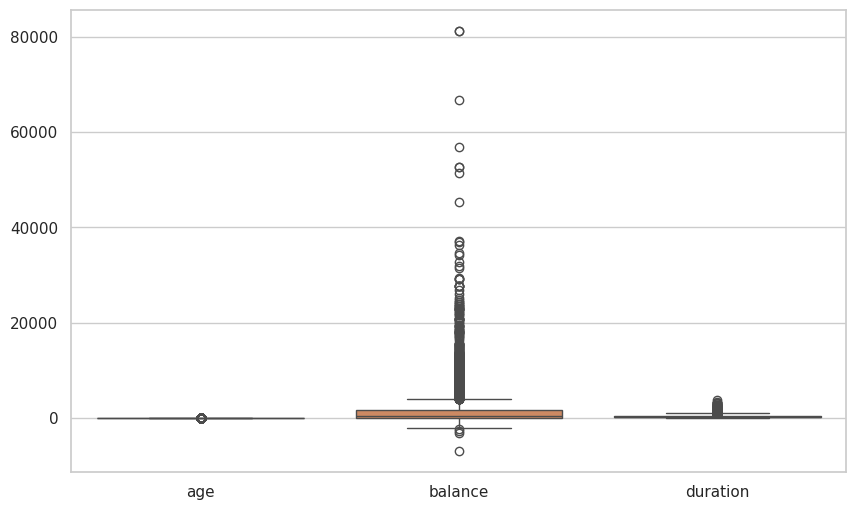

In [56]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['age', 'balance', 'duration']])

plt.show()

In [57]:
Q1_age = df['age'].quantile(0.25)
Q3_age = df['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
df = df[(df['age'] >= Q1_age - 1.5 * IQR_age) & (df['age'] <= Q3_age + 1.5 * IQR_age)]

Q1_bal = df['balance'].quantile(0.25)
Q3_bal = df['balance'].quantile(0.75)
IQR_bal = Q3_bal - Q1_bal
df = df[(df['balance'] >= Q1_bal - 1.5 * IQR_bal) & (df['balance'] <= Q3_bal + 1.5 * IQR_bal)]

Q1_dur = df['duration'].quantile(0.25)
Q3_dur = df['duration'].quantile(0.75)
IQR_dur = Q3_dur - Q1_dur
df = df[(df['duration'] >= Q1_dur - 1.5 * IQR_dur) & (df['duration'] <= Q3_dur + 1.5 * IQR_dur)]

In [58]:
df.shape

(9373, 17)

In [59]:
for col in df.columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f"{col}: {count} 'unknown'")

job: 56 'unknown'
education: 399 'unknown'
contact: 2007 'unknown'
poutcome: 6979 'unknown'


In [60]:
jobs = df['job'].mode()[0]
df['job'] = df['job'].replace('unknown', jobs)

education = df['education'].mode()[0]
df['education'] = df['education'].replace('unknown', education)

In [64]:
df['contacted'] = np.where(df['pdays'] == -1,0,1)

binary_cols = ['deposit', 'default', 'housing', 'loan']
for col in binary_cols:
  df[col] = df[col].map({'yes': 1, 'no': 0})

In [66]:
categorical_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [69]:
df = df.drop(columns=['pdays'])

In [70]:
df

,age,default,balance,housing,loan,day,duration,campaign,previous,deposit,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
3,55,0,2476,1,0,5,579,1,0,1,...,False,False,False,True,False,False,False,False,False,True
4,54,0,184,0,0,5,673,2,0,1,...,False,False,False,True,False,False,False,False,False,True
5,42,0,0,1,1,5,562,2,0,1,...,False,False,False,True,False,False,False,False,False,True
8,37,0,1,1,0,6,608,1,0,1,...,False,False,False,True,False,False,False,False,False,True
10,38,0,100,1,0,7,786,1,0,1,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,0,1,1,0,20,257,1,0,0,...,False,False,False,False,False,False,False,False,False,True
11158,39,0,733,0,0,16,83,4,0,0,...,False,True,False,False,False,False,False,False,False,True
11159,32,0,29,0,0,19,156,2,0,0,...,False,False,False,False,False,False,False,False,False,True
11160,43,0,0,0,1,8,9,2,5,0,...,False,False,False,True,False,False,False,False,False,False


In [75]:
from sklearn.preprocessing import StandardScaler

In [76]:
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'previous']

scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [78]:
df[numerical_cols].head()

,age,balance,day,duration,campaign,previous
3,1.338423,1.705785,-1.252276,1.157024,-0.552531,-0.370309
4,1.246920,-0.619132,-1.252276,1.557859,-0.186869,-0.370309
5,0.148877,-0.805775,-1.252276,1.084532,-0.186869,-0.370309
8,-0.308640,-0.804760,-1.134291,1.280685,-0.552531,-0.370309
10,-0.217137,-0.704338,-1.016307,2.039713,-0.552531,-0.370309


In [79]:
X = df.drop(columns=['deposit'])
y = df['deposit']

In [80]:
from sklearn.model_selection import train_test_split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = .2,
    random_state = 42,
    stratify = y
)

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [84]:
model = LogisticRegression(random_state=42, max_iter = 1000)

In [85]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [86]:
y_pred = model.predict(X_test)

In [87]:
accuracy = accuracy_score(y_test, y_pred)

In [88]:
print(accuracy)

0.8517333333333333


In [89]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1065
           1       0.84      0.81      0.83       810

    accuracy                           0.85      1875
   macro avg       0.85      0.85      0.85      1875
weighted avg       0.85      0.85      0.85      1875

